In [1]:
import numpy as np
np.testing.Tester = np.testing.TestCase
import pandas as pd
import json
import scipy
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from feos.si import * # SI numbers and constants
#from si_units import * # SI numbers and constants

from feos.pcsaft import *
from feos.eos import *

from moth import *

msize=12
mwidth = 2
fsize=16
alpha=0.3
lsize = 2
framewidth = 3
markeredgewidth=3
markeredgewidth_no=10

In [ ]:
"""
choose specie, parameter-source and path
"""

saft_paras = "20191105_pure_parameters_feos.json"

name = "butanol"
name = "propanol"

name = "hexane"
name = "water"

name = "heptane"

name = "dodecane"


savepath = "results_base/"


In [3]:
"""
build path to save results
"""
try:
    os.mkdir(savepath)
except:
    None

try:
    os.mkdir(savepath+"/"+name)
except:
    None

'dodecane'

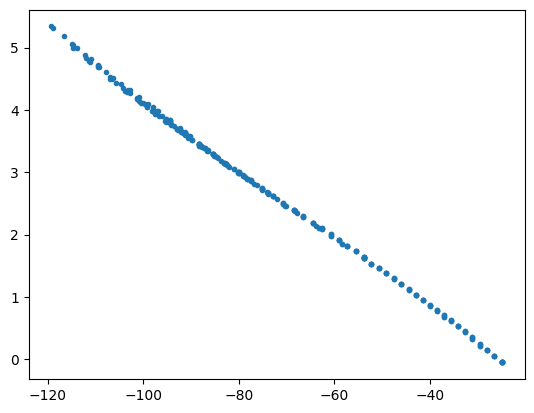

In [ ]:
"""
load and process data

"""

parameters = PcSaftParameters.from_json(
    [name.split("_")[0]], 
    saft_paras, 
    #search_option="name"
)

M = parameters.pure_records[0].molarweight *(GRAM/MOL)
m = parameters.pure_records[0].model_record.m

ppath = "experimental/"+name+"/"+name+"_viscosity_proc.csv"

data = pd.read_csv(ppath)

#plt.plot( data["temperature"], np.log(data["pressure"]), "." )
plt.plot( data["s_res"], np.log(data["viscosity"]/data["eta_CE"]), "." )
name

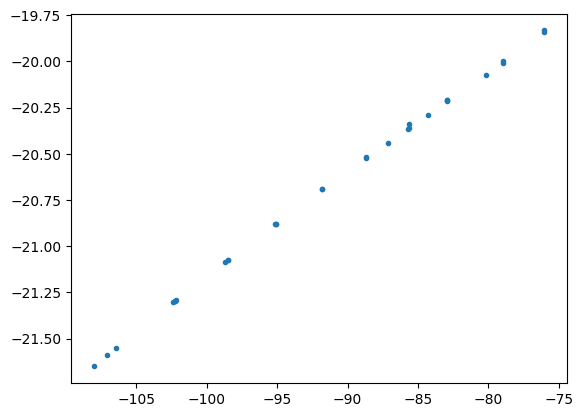

In [ ]:

ppath = "experimental/"+name+"/"+name+"_diffusion.csv"


diff_dat = pd.read_csv(ppath)

plt.plot( diff_dat["s_res"], np.log(diff_dat["D"]), "." )


dodecane & x & 293.15 & 593.2 & 1.0 & 1917.4 & 14.34 & 4.46\\


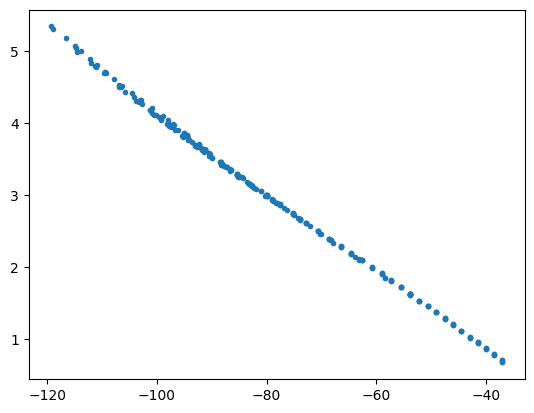

In [6]:
"""
exclude:

- not converged state points
- state points above the pressure limit

"""
eos = EquationOfState.pcsaft(parameters)

critical_point = State.critical_point(eos)

T_crit = critical_point.temperature / KELVIN
rho_crit = critical_point.density *(METER**3/MOL)
V_crit = 1/rho_crit
V_crit

data = data[  data["s_res"] < -0.1  ] # exclude not converged (iG) datapoints
dummy = data[  data["s_res"] < -8  ] # exclude not converged (iG) datapoints
#dummy = data[  data["s_res"] > -120  ]
dummy = dummy[  dummy["pressure"] < 2e8  ]
#dummy = dummy[dummy["state"]=="L"]
dummy = dummy[dummy["temperature"]<0.9*T_crit]

if name=="propanol":
    dummy = dummy[  dummy["s_res"] < -50  ]

plt.plot( dummy["s_res"], np.log(dummy["viscosity"]/dummy["eta_CE"]), "." )


maxs = dummy.max(axis=0)
mins = dummy.min(axis=0)
mima = [ str(round(mins["temperature"],2)), str(round(maxs["temperature"],2)),
         str(round(mins["pressure"]/1e5,2)), str(round(maxs["pressure"]/1e5,2)),
         str(round( -mins["s_res"]/8.314,2)), str(round(-maxs["s_res"]/8.314,2))
       ]
print( name+" & x & "+" & ".join(mima) +"\\\\"  )

In [ ]:
"""

Choose and train Eyring model

Model overview:

EyringEntropyModel: EES1 with diffusion
EyringEntropyModel_EES1: EES1 without diffusion
EyringEntropyModel_EES0: EES0 with diffusion

"""

# NOTE propane is propane bell here
poly_dict = {
    "propane": [3.51848530e+00,  8.98719202e-01, -6.57541675e-02,  4.85748207e-03,
       -3.89815685e-02,  3.23990347e-04,  2.68096625e-05],
    "butane": [2.93675606e+00,  6.58606541e-01, -3.54757854e-02,  3.43297168e-03,
       -2.34423967e-02, -3.20780717e-09,  2.77658981e-06],
    "hexane": [  3.201e+00 , 6.538e-01, -2.872e-02,  2.056e-03, -3.439e-02, -2.500e-09 , 9.602e-06],
    "heptane": [3.14259960e+00,  5.87862794e-01, -2.91491603e-02,  2.08778638e-03,
       -1.44664705e-02, -1.24873294e-19, -1.24873294e-19],
    "octane": [ 3.26730119e+00,  6.05701436e-01, -2.67738775e-02,  1.79895834e-03,
       -2.85554249e-02, -8.00307969e-19, -8.00307969e-19],
    "nonane": [ 3.25593263e+00,  5.94314410e-01, -3.34719291e-02,  2.06303415e-03,
       -1.34864713e-02, -7.79506607e-19, -7.79506607e-19],
    "dodecane": [ 3.14613724e+00,  4.33415774e-01, -1.43774533e-02,  8.43063298e-04,
        6.78612430e-03, -9.35159214e-05, -4.08358569e-06 ],
    "propanol":[3.1066556182709726, 0.3339730333762955, 0.009245313934974447, 0.0013849394768765822, -0.047430508899753754, -0.0005883123087159559, -3.303476589905937e-05],
    "butanol": [ 3.09736418e+00,  5.16332669e-01, -1.12147937e-02,  1.86113048e-03,
        -9.89413889e-02,  1.41800551e-07,  2.59356047e-06],
     "carbondioxide": [ 2.43423933e+00,  1.00134140e-01,  9.41409197e-02, -5.46421374e-03,
        8.63269060e-02, -1.07508664e-02,  4.90355962e-04],
     "water": [ 4.02290363e+00,  3.74513465e-01, -1.00705969e-01,  2.27679907e-03,
        1.80066136e-01,  7.67372189e-03,  5.27146621e-05],
    "water_new2": [4.03210064e+00,  3.71941896e-01, -1.03863165e-01,  2.68905680e-03,
        1.76920251e-01,  8.88540130e-03,  9.45182114e-07],      
    "water_hbond": [4.14071517e+00,  3.08348513e-01, -6.26207933e-02,  5.13599738e-03,
        1.60000000e-01,  8.43927589e-06,  1.00000000e-04],
    "water_hbond_fix":[ 4.17987307e+00,  2.73614916e-01, -9.99996458e-02,  1.30869622e-02, 0, 0, 0 ],
}



ppp = poly_dict.get(name, [ 3, 0.0, 1.0, .1, .1])



model = MotH(parameters, dummy, p=ppp, data_diffusion=diff_dat, )


# train on viscosity
#model.train()

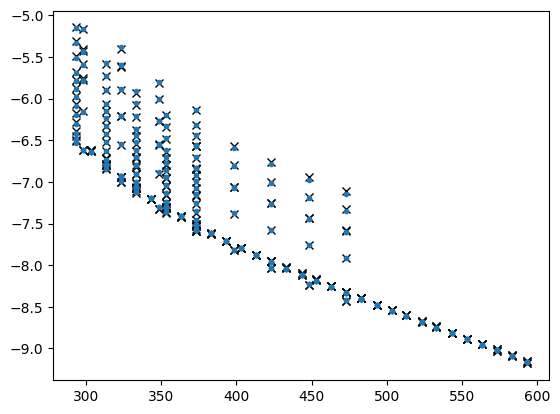

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

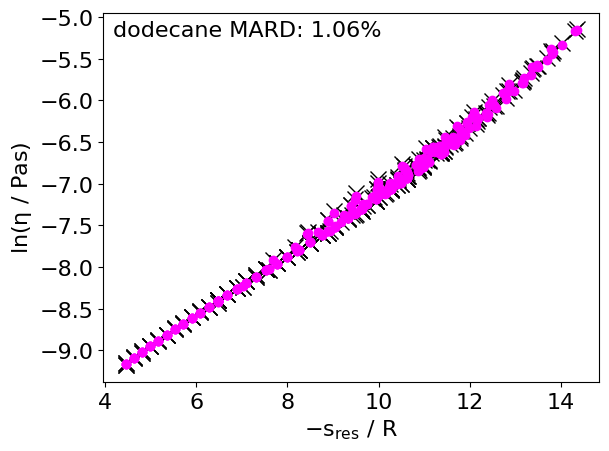

np.float64(1.0623509254558734)

In [8]:
"""
predict and show results plus error

"""

y_pred = model.predict()

plt.plot(model.data["temperature"],np.log(model.data["viscosity"]),"kx")
plt.plot(model.data["temperature"],y_pred,".")
plt.show()
plt.close()

fig, ax = plt.subplots()

plt.plot(-model.data["s_res"]/8.314,np.log(model.data["viscosity"]),"kx",markersize=msize)
plt.plot(-model.data["s_res"]/8.314,y_pred,".",color="magenta",markersize=msize)

plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln(\eta~/~Pas)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred) - model.data["viscosity"]) / model.data["viscosity"] ))*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  


plt.savefig(savepath+"/"+name+"/"+name+"_eyring_entropy.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_eyring_entropy.pdf",bbox_inches='tight')

plt.show()
plt.close()  


error

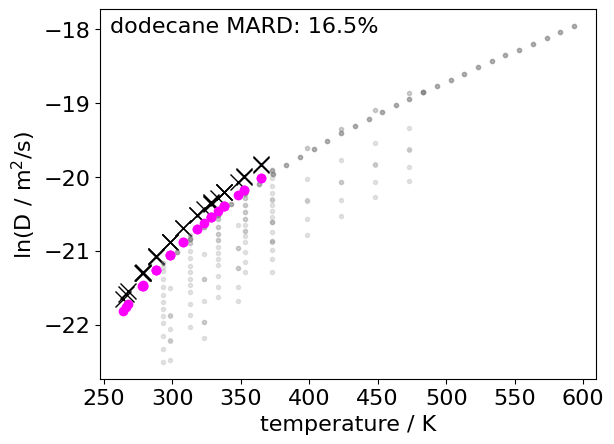

np.float64(16.497191998578543)

In [9]:
"""
predict diffusion

NOTE: leads to error if diffusion is not implemented ;) Then skip...
"""

y_pred = model.predict_diffusion()
y_pred_D = model.predict_diffusion(data = diff_dat)

x = - diff_dat["s_res"]/8.314
xx = ppp[1]*x + ppp[2]*x*x + ppp[3]*x*x*x
dummy = y_pred_D - 1/3*xx


fig, ax = plt.subplots()

plt.plot(diff_dat["temperature"], np.log(diff_dat["D"]),"kx",markersize=msize)
plt.plot(model.data["temperature"],y_pred,".",color="grey",alpha=0.2)
plt.plot(diff_dat["temperature"],y_pred_D,".",color="magenta",markersize=msize)

#plt.plot(diff_dat["temperature"], dummy,".",color="r",markersize=msize)


plt.xlabel(r"temperature / K",fontsize=fsize)
plt.ylabel(r"$\ln(D~/~m^2/s)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred_D) - diff_dat["D"]) / diff_dat["D"] ))
error = error*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"/"+name+"/"+name+"_eyring_entropy_diffusion.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_eyring_entropy_diffusion.pdf",bbox_inches='tight')


plt.show()
plt.close()

error

In [11]:
model.p

[3.14613724,
 0.433415774,
 -0.0143774533,
 0.000843063298,
 0.0067861243,
 -9.35159214e-05,
 -4.08358569e-06]

In [12]:
model.train_diffusion()

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 13660431.470235944
        x: [ 1.198e+00]
      nit: 7
      jac: [ 0.000e+00]
     nfev: 18
     njev: 9
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

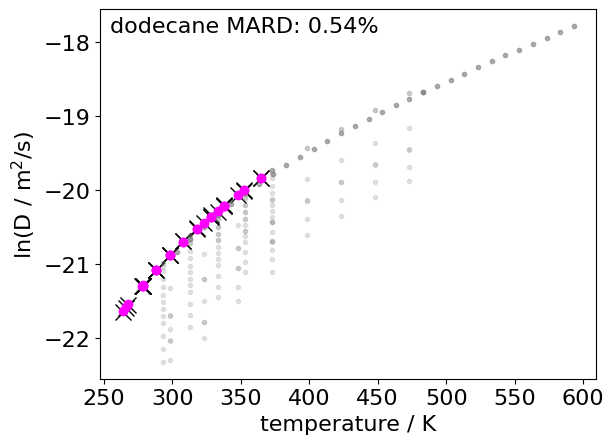

np.float64(0.5372520310836406)

In [13]:
"""
predict diffusion

NOTE: leads to error if diffusion is not implemented ;) Then skip...
"""

y_pred = model.predict_diffusion()
y_pred_D = model.predict_diffusion(data = diff_dat)

fig, ax = plt.subplots()

plt.plot(diff_dat["temperature"], np.log(diff_dat["D"]),"kx",markersize=msize)
plt.plot(model.data["temperature"],y_pred,".",color="grey",alpha=0.2)
plt.plot(diff_dat["temperature"],y_pred_D,".",color="magenta",markersize=msize)

plt.xlabel(r"temperature / K",fontsize=fsize)
plt.ylabel(r"$\ln(D~/~m^2/s)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred_D) - diff_dat["D"]) / diff_dat["D"] ))
error = error*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"/"+name+"/"+name+"_eyring_entropy_diffusion_train.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_eyring_entropy_diffusion_train.pdf",bbox_inches='tight')


plt.show()
plt.close()

error

In [14]:
model.dd

array([1.19759176])

In [15]:
1/model.dd

array([0.83500908])

In [16]:
model.train_both()

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 2094029.4728720908
        x: [ 3.146e+00  4.344e-01 -1.470e-02  8.628e-04  7.545e-03
            -1.571e-04 -2.727e-06  1.198e+00]
      nit: 5
      jac: [ 7.911e+06 -8.337e+06  5.674e+08  8.630e+09  1.467e+07
             8.954e+08 -6.547e+08  1.491e+06]
 hess_inv: [[ 9.897e-01  4.178e-02 ...  7.790e-05  3.005e-03]
            [ 4.178e-02  8.236e-01 ... -3.622e-04 -1.726e-02]
            ...
            [ 7.790e-05 -3.622e-04 ...  2.222e-07 -2.233e-04]
            [ 3.005e-03 -1.726e-02 ... -2.233e-04  9.999e-01]]
     nfev: 318
     njev: 34

In [17]:
model.p

array([ 3.14591950e+00,  4.34423685e-01, -1.46963508e-02,  8.62769674e-04,
        7.54517891e-03, -1.57143063e-04, -2.72744221e-06])

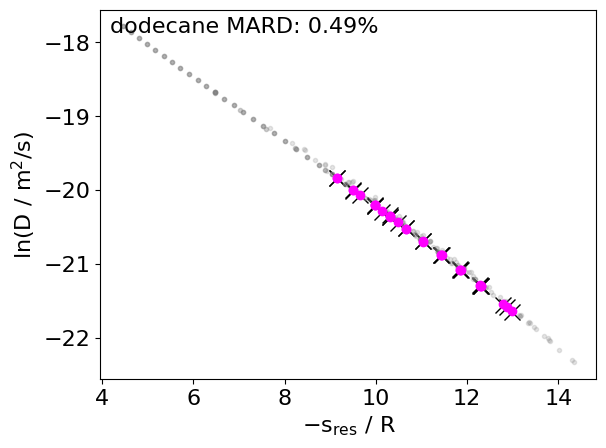

np.float64(0.4887152438202644)

In [18]:
"""
predict diffusion

NOTE: leads to error if diffusion is not implemented ;) Then skip...
"""

y_pred = model.predict_diffusion()
y_pred_D = model.predict_diffusion(data = diff_dat)

fig, ax = plt.subplots()

plt.plot(-diff_dat["s_res"]/8.314, np.log(diff_dat["D"]),"kx",markersize=msize)
plt.plot(-model.data["s_res"]/8.314,y_pred,".",color="grey",alpha=0.2)
plt.plot(-diff_dat["s_res"]/8.314,y_pred_D,".",color="magenta",markersize=msize)

# plt.xlabel(r"temperature / K",fontsize=fsize)
plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln(D~/~m^2/s)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred_D) - diff_dat["D"]) / diff_dat["D"] ))
error = error*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"/"+name+"/"+name+"_eyring_entropy_diffusion_both.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_eyring_entropy_diffusion_both.pdf",bbox_inches='tight')


plt.show()
plt.close()

error

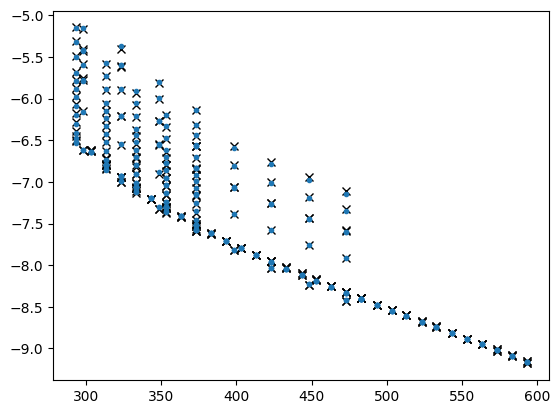

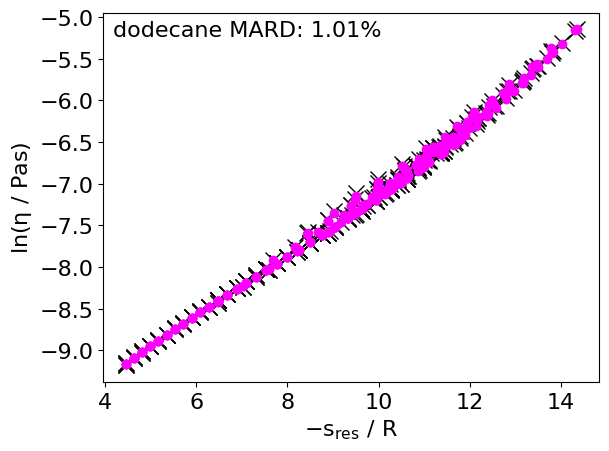

np.float64(1.0141448756651597)

In [19]:
"""
predict and show results plus error

"""

y_pred = model.predict()

plt.plot(model.data["temperature"],np.log(model.data["viscosity"]),"kx")
plt.plot(model.data["temperature"],y_pred,".")
plt.show()
plt.close()

fig, ax = plt.subplots()

plt.plot(-model.data["s_res"]/8.314,np.log(model.data["viscosity"]),"kx",markersize=msize)
plt.plot(-model.data["s_res"]/8.314,y_pred,".",color="magenta",markersize=msize)

plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln(\eta~/~Pas)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred) - model.data["viscosity"]) / model.data["viscosity"] ))*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  


plt.savefig(savepath+"/"+name+"/"+name+"_eyring_entropy_both.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_eyring_entropy_both.pdf",bbox_inches='tight')

plt.show()
plt.close()  

error